In [ ]:
pip install open3d

In [4]:
pip install ultralytics


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --- ------------------------------------ 0.1/1.1 MB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 0.1/1.1 MB 2.2 MB/s eta 0:00:01
   ---- ----------------------------------- 0.1/1.1 MB 2.2 MB/s eta 0:00:01
   ---- ----------------------------------- 0.1/1.1 MB 804.6 kB/s eta 0:00:02
   ----- ---------------------------------- 0.1/1.1 MB 711.9 kB/s eta 0:00:02
   ----- ---------------------------------- 0.1/1.1 MB 711.9 kB/s eta 0:00:02
   --------- ------------------------------ 0.2/1.1 MB 754.9 kB/s eta 0:00:02
   --------- ------------------------------ 0.2/1.1 MB 754.9 kB/s eta 0:00:02
   ------------- -------------------------- 0.4/1.1 MB 882.8 kB/s eta 0:00:01
   ------------- ------------------------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import open3d as o3d
import cv2  
import os
import pandas as pd
import matplotlib.pyplot as plt 

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [13]:
# --- 1. Tham số nội tại camera màu (color_intrinsics) ---
# cần để chiếu (project) file PLY lên ảnh 2D.
color_intrinsics = {
    'fx': 643.90087890625,
    'fy': 643.1365356445312,
    'cx': 650.2113037109375,
    'cy': 355.79559326171875,
    'width': 1280,
    'height': 720
}

# ( không cần 'depth_intrinsics' hoặc 'extrinsics'
# vì dùng file PLY đã được căn chỉnh (registered) sẵn)

# --- 2. Định nghĩa vùng quan tâm (ROI) ---
# (X, Y, W, H) = (560, 150, 300, 330)
ROI_X_MIN = 560
ROI_Y_MIN = 150
ROI_W = 300
ROI_H = 330

# Tính toán tọa độ tối đa để dễ kiểm tra
ROI_X_MAX = ROI_X_MIN + ROI_W  # 860
ROI_Y_MAX = ROI_Y_MIN + ROI_H  # 480

print(f"ROI được định nghĩa: X ({ROI_X_MIN}, {ROI_X_MAX}), Y ({ROI_Y_MIN}, {ROI_Y_MAX})")

# --- 3. Định nghĩa các đường dẫn (Paths) ---
BASE_DATA_PATH = r"C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train"
RGB_PATH = os.path.join(BASE_DATA_PATH, "rgb")
DEPTH_PATH = os.path.join(BASE_DATA_PATH, "depth")
PLY_PATH = os.path.join(BASE_DATA_PATH, "ply")

print(f"Đường dẫn dữ liệu: {BASE_DATA_PATH}")

ROI được định nghĩa: X (560, 860), Y (150, 480)
Đường dẫn dữ liệu: C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train


In [22]:
from ultralytics import YOLO

MODEL_PATH = r"C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\source_lam\yolov8s-seg.pt"

try:
    model = YOLO(MODEL_PATH)
    print(f"Đã tải thành công mô hình từ: {MODEL_PATH}")
except Exception as e:
    print(f"LỖI: Không thể tải mô hình. Đảm bảo đường dẫn '{MODEL_PATH}' là chính xác.")
    print(f"Chi tiết lỗi: {e}")



Đã tải thành công mô hình từ: C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\source_lam\yolov8s-seg.pt


Đang chuẩn bị tải dữ liệu cho: 0012.png
Đường dẫn RGB: C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\rgb\0012.png
Đường dẫn PLY: C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\ply\0012.ply

[THÀNH CÔNG] Tải ảnh RGB. Kích thước: (720, 1280, 3)
[THÀNH CÔNG] Tải Point Cloud. Số điểm: 677185

Hiển thị ảnh RGB (đã chuyển sang hệ màu RGB):


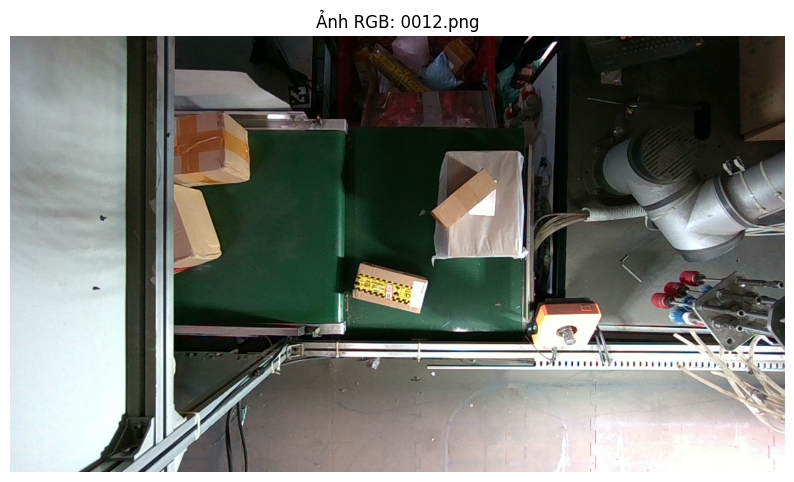


5 điểm 3D đầu tiên (x, y, z) từ file PLY:
[[   -0.50019     0.99507      -1.827]
 [   -0.49741     0.99509      -1.827]
 [    -0.4949     0.99564      -1.828]
 [   -0.49319     0.99783      -1.832]
 [   -0.49066     0.99839      -1.833]]


In [23]:
IMAGE_FILENAME = "0012.png"  

rgb_file_path = os.path.join(RGB_PATH, IMAGE_FILENAME)

base_filename = os.path.splitext(IMAGE_FILENAME)[0] 
ply_filename = base_filename + ".ply"
ply_file_path = os.path.join(PLY_PATH, ply_filename)

print(f"Đang chuẩn bị tải dữ liệu cho: {IMAGE_FILENAME}")
print(f"Đường dẫn RGB: {rgb_file_path}")
print(f"Đường dẫn PLY: {ply_file_path}")

try:
    rgb_image_bgr = cv2.imread(rgb_file_path)
    
    if rgb_image_bgr is None:
        raise FileNotFoundError(f"Không tìm thấy file ảnh hoặc file bị hỏng: {rgb_file_path}")
    
    rgb_image_rgb = cv2.cvtColor(rgb_image_bgr, cv2.COLOR_BGR2RGB)
    
    print(f"\n[THÀNH CÔNG] Tải ảnh RGB. Kích thước: {rgb_image_rgb.shape}")

except Exception as e:
    print(f"\n[LỖI] Không thể tải ảnh RGB: {e}")

try:
    pcd_full = o3d.io.read_point_cloud(ply_file_path)
    
    if not pcd_full.has_points():
        raise FileNotFoundError(f"Không tìm thấy file PLY hoặc file rỗng: {ply_file_path}")
    
    full_points_3d = np.asarray(pcd_full.points)
    
    print(f"[THÀNH CÔNG] Tải Point Cloud. Số điểm: {len(full_points_3d)}")

except Exception as e:
    print(f"\n[LỖI] Không thể tải file PLY: {e}")


if 'rgb_image_rgb' in locals():
    print("\nHiển thị ảnh RGB (đã chuyển sang hệ màu RGB):")
    plt.figure(figsize=(10, 6)) 
    plt.imshow(rgb_image_rgb)
    plt.title(f"Ảnh RGB: {IMAGE_FILENAME}")
    plt.axis('off') 
    plt.show()
else:
    print("\nKhông thể hiển thị ảnh do lỗi tải dữ liệu ở trên.")

if 'full_points_3d' in locals():
    print("\n5 điểm 3D đầu tiên (x, y, z) từ file PLY:")
    print(full_points_3d[:5])

Đang chạy model trên ảnh: 0012.png...

0: 384x640 1 tv, 206.3ms
Speed: 2.1ms preprocess, 206.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)
[THÀNH CÔNG] Model đã chạy xong.
Model phát hiện tổng cộng 1 vật thể (với conf > 0.5).
---
[KẾT QUẢ BƯỚC 2]: Tìm thấy 1 ứng cử viên có TÂM 2D nằm trong ROI.


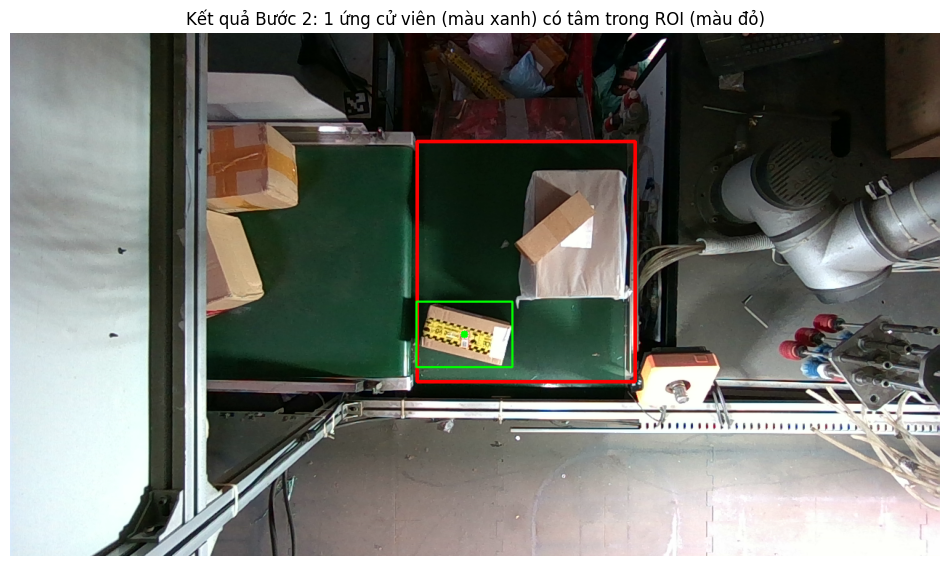

In [25]:
print(f"Đang chạy model trên ảnh: {IMAGE_FILENAME}...")
try:
    results = model(rgb_image_rgb, conf=0.5) 
    result = results[0]
    
    print("[THÀNH CÔNG] Model đã chạy xong.")
except Exception as e:
    print(f"[LỖI] Model gặp lỗi khi chạy: {e}")
    
    raise e

candidates_2d = []

if result.boxes is None or result.masks is None:
    print("Model không phát hiện được vật thể nào (hoặc không trả về mask).")
else:
    
    boxes_xyxy = result.boxes.xyxy.cpu().numpy()

    masks_data = result.masks.data.cpu().numpy() 
    
    print(f"Model phát hiện tổng cộng {len(boxes_xyxy)} vật thể (với conf > 0.5).")
    
    for i in range(len(boxes_xyxy)):
        box = boxes_xyxy[i]
    
        x1, y1, x2, y2 = box
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        is_in_roi = (center_x >= ROI_X_MIN and center_x < ROI_X_MAX) and \
                    (center_y >= ROI_Y_MIN and center_y < ROI_Y_MAX)
        
      
        if is_in_roi:
            
            mask_probability = masks_data[i] 
            
            mask_binary = (mask_probability > 0.5).astype(np.uint8)
            
            candidates_2d.append({
                'box': box,
                'mask': mask_binary, 
                'center_2d': (center_x, center_y)
            })

    print(f"---")
    print(f"[KẾT QUẢ BƯỚC 2]: Tìm thấy {len(candidates_2d)} ứng cử viên có TÂM 2D nằm trong ROI.")

if 'rgb_image_rgb' in locals():
    
    viz_image = rgb_image_rgb.copy()
    
    cv2.rectangle(
        viz_image,
        (ROI_X_MIN, ROI_Y_MIN), # Điểm (x, y) trên cùng bên trái
        (ROI_X_MAX, ROI_Y_MAX), # Điểm (x, y) dưới cùng bên phải
        (255, 0, 0), # Màu ĐỎ (BGR)
        3            # Độ dày
    )
    
    for cand in candidates_2d:
        box = cand['box'].astype(int)
        center = cand['center_2d']
        
        # Vẽ bounding box
        cv2.rectangle(viz_image, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        
        # Vẽ điểm tâm 2D
        cv2.circle(viz_image, (int(center[0]), int(center[1])), 5, (0, 255, 0), -1)
            
    plt.figure(figsize=(12, 8))
    plt.imshow(viz_image)
    plt.title(f"Kết quả Bước 2: {len(candidates_2d)} ứng cử viên (màu xanh) có tâm trong ROI (màu đỏ)")
    plt.axis('off')
    plt.show()
else:
    print("Biến 'rgb_image_rgb' không tồn tại để vẽ.")

In [28]:


if 'full_points_3d' in locals() and len(full_points_3d) > 0:
    print(f"Kiểm tra {len(full_points_3d)} điểm 3D đã tải ở Bước 1...")
    
    print("\n5 điểm 3D đầu tiên (X, Y, Z):")
    print(full_points_3d[:5])
    
    x_col = full_points_3d[:, 0]
    y_col = full_points_3d[:, 1]
    z_col = full_points_3d[:, 2]
    
    print("\n--- Phân tích cột 0 (Nghi là X): ---")
    print(f"  Min: {np.min(x_col):.4f}")
    print(f"  Max: {np.max(x_col):.4f}")
    print(f"  Mean: {np.mean(x_col):.4f}")
    
    print("\n--- Phân tích cột 1 (Nghi là Y): ---")
    print(f"  Min: {np.min(y_col):.4f}")
    print(f"  Max: {np.max(y_col):.4f}")
    print(f"  Mean: {np.mean(y_col):.4f}")
    
    print("\n--- Phân tích cột 2 (Nghi là Z - Độ sâu?): ---")
    print(f"  Min: {np.min(z_col):.4f}")
    print(f"  Max: {np.max(z_col):.4f}")
    print(f"  Mean: {np.mean(z_col):.4f}")
    
else:
    print("LỖI: Biến 'full_points_3d' không tồn tại hoặc rỗng. Hãy chạy lại Bước 1.")

Kiểm tra 677185 điểm 3D đã tải ở Bước 1...

5 điểm 3D đầu tiên (X, Y, Z):
[[   -0.50019     0.99507      -1.827]
 [   -0.49741     0.99509      -1.827]
 [    -0.4949     0.99564      -1.828]
 [   -0.49319     0.99783      -1.832]
 [   -0.49066     0.99839      -1.833]]

--- Phân tích cột 0 (Nghi là X): ---
  Min: -57.6313
  Max: 1.1658
  Mean: 0.1116

--- Phân tích cột 1 (Nghi là Y): ---
  Min: -8.9144
  Max: 29.3325
  Mean: 0.0390

--- Phân tích cột 2 (Nghi là Z - Độ sâu?): ---
  Min: -65.5350
  Max: -0.4930
  Mean: -1.1813


In [32]:
# full_points_3d: (N x 3) Mảng NumPy từ Bước 1
# color_intrinsics: Dict chứa fx, fy, cx, cy từ Bước 0
# candidates_2d: Danh sách các ứng cử viên 2D từ Bước 2

print("Bắt đầu Bước 3: Trích xuất Point Cloud 3D...")

print(f"Đang chiếu {len(full_points_3d)} điểm 3D xuống 2D...")

fx = color_intrinsics['fx']
fy = color_intrinsics['fy']
cx = color_intrinsics['cx']
cy = color_intrinsics['cy']

x = full_points_3d[:, 0]
y = full_points_3d[:, 1]
z = full_points_3d[:, 2]

valid_z_mask = z < -0.001 

valid_points_3d = full_points_3d[valid_z_mask]

original_indices_map = np.where(valid_z_mask)[0]

x_valid = valid_points_3d[:, 0]
y_valid = valid_points_3d[:, 1]
z_valid = valid_points_3d[:, 2]

u = (x_valid * fx / z_valid) + cx
v = (y_valid * fy / z_valid) + cy

projected_cols = u.astype(int)
projected_rows = v.astype(int)

print(f"Chiếu thành công {len(projected_cols)} điểm 3D hợp lệ.")

print(f"Đang lọc điểm 3D cho {len(candidates_2d)} ứng cử viên 2D...")

candidate_parcels_info = []

if len(candidates_2d) > 0:
    h, w = candidates_2d[0]['mask'].shape
else:
    h, w = (color_intrinsics['height'], color_intrinsics['width'])

in_bounds_mask = (projected_rows >= 0) & (projected_rows < h) & \
                 (projected_cols >= 0) & (projected_cols < w)

rows_in_bounds = projected_rows[in_bounds_mask]
cols_in_bounds = projected_cols[in_bounds_mask]
original_indices_in_bounds = original_indices_map[in_bounds_mask]

print(f"  -> {len(rows_in_bounds)} điểm 3D chiếu vào trong khung ảnh.")

for i, cand in enumerate(candidates_2d):
    mask_2d = cand['mask']
    
    # Dùng "fancy indexing" của NumPy để lấy giá trị mask tại TẤT CẢ các điểm 2D
    # mask_values sẽ là một mảng (0, 0, 1, 0, 1, 1...)
    mask_values = mask_2d[rows_in_bounds, cols_in_bounds]
    
    # Chỉ lấy các điểm có giá trị mask == 1 (nằm bên trong mask)
    points_in_mask_bool = (mask_values == 1)
    
    # Lấy chỉ số GỐC (từ full_points_3d) của các điểm này
    final_original_indices = original_indices_in_bounds[points_in_mask_bool]
    
    # Dùng chỉ số gốc để "nhặt" các điểm 3D
    parcel_points_3d = full_points_3d[final_original_indices]
    
    print(f"  -> Ứng cử viên {i}: Tìm thấy {len(parcel_points_3d)} điểm 3D.")

    candidate_parcels_info.append({
        '2d_info': cand,          # Thông tin 2D (box, mask, center)
        'points_3d': parcel_points_3d # Mảng NumPy (K x 3) chứa điểm 3D
    })

print(f"\n[KẾT QUẢ BƯỚC 3]: Đã trích xuất PoinCloud 3D cho {len(candidate_parcels_info)} ứng cử viên.")

if len(candidate_parcels_info) > 0:
    print("Đang hiển thị Point Cloud 3D của ứng cử viên đầu tiên...")
    
    # Lấy points 3D của ứng cử viên đầu tiên
    points_to_show = candidate_parcels_info[0]['points_3d']
    
    if len(points_to_show) > 0:
        # Tạo đối tượng PointCloud của Open3D
        pcd_parcel = o3d.geometry.PointCloud()
        
        # Nạp các điểm 3D vào
        pcd_parcel.points = o3d.utility.Vector3dVector(points_to_show)
        
        # Ước tính vector pháp tuyến (để tô màu cho đẹp)
        pcd_parcel.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
        
        # Hiển thị
        o3d.visualization.draw_geometries([pcd_parcel], 
                                          window_name=f"Buoc 3: {len(points_to_show)} diem 3D",
                                          point_show_normal=True) # Hiển thị cả pháp tuyến
    else:
        print("LỖI: Ứng cử viên này có mask nhưng không có điểm 3D nào tương ứng.")
else:
    print("Không có ứng cử viên nào để hiển thị 3D.")

Bắt đầu Bước 3: Trích xuất Point Cloud 3D...
Đang chiếu 677185 điểm 3D xuống 2D...
Chiếu thành công 677185 điểm 3D hợp lệ.
Đang lọc điểm 3D cho 1 ứng cử viên 2D...
  -> 207758 điểm 3D chiếu vào trong khung ảnh.
  -> Ứng cử viên 0: Tìm thấy 2510 điểm 3D.

[KẾT QUẢ BƯỚC 3]: Đã trích xuất PoinCloud 3D cho 1 ứng cử viên.
Đang hiển thị Point Cloud 3D của ứng cử viên đầu tiên...


In [30]:

from scipy.spatial.transform import Rotation as R

print("Bắt đầu Bước 4: Tính toán Tâm 3D và Hướng Gắp...")

final_candidates = []

for i, parcel_info in enumerate(candidate_parcels_info):
    
    parcel_points_3d = parcel_info['points_3d']
    
    # Kiểm tra xem có đủ điểm để tính RANSAC không
    if len(parcel_points_3d) < 100: # Cần ít nhất 100 điểm
        print(f"  -> Bỏ qua ứng cử viên {i}: Chỉ có {len(parcel_points_3d)} điểm, không đủ để fit mặt phẳng.")
        continue

    # --- a. Tính Tâm 3D (Cho MCE - 70% điểm) ---
    # Lấy trung bình cộng của TẤT CẢ các điểm 3D thuộc bưu kiện
    center_3d = np.mean(parcel_points_3d, axis=0)
    
    # --- b. Fit Mặt Phẳng (Cho OE - 30% điểm) ---
    # Tạo đối tượng PointCloud của Open3D
    pcd_parcel = o3d.geometry.PointCloud()
    pcd_parcel.points = o3d.utility.Vector3dVector(parcel_points_3d)
    
    # Dùng RANSAC để tìm mặt phẳng
    try:
        plane_model, inliers = pcd_parcel.segment_plane(
            distance_threshold=0.01, # 1 cm (ngưỡng khoảng cách từ điểm đến mặt phẳng)
            ransac_n=3,              # Dùng 3 điểm để định nghĩa mặt phẳng
            num_iterations=1000      # Số lần lặp
        )
        # plane_model trả về [a, b, c, d] của phương trình mặt phẳng ax + by + cz + d = 0
        [a, b, c, d] = plane_model
        normal_vector = np.array([a, b, c])
        
    except Exception as e:
        print(f"  -> Lỗi khi chạy RANSAC cho ứng cử viên {i}: {e}. Bỏ qua.")
        continue
        
    # --- c. Chuẩn hóa Hướng Vector ---
    # Đề bài: "luôn hướng vào phía vật thể"
    # Quy ước : Luôn hướng về phía camera (tức là $z$ dương,
    # vì camera ở z=0 và vật thể ở z âm)
    
    if normal_vector[2] < 0:
        # Nếu z của vector là âm (hướng xa camera), lật ngược nó lại
        normal_vector = -normal_vector
        
    # Chuẩn hóa vector (đưa về độ dài bằng 1)
    normal_vector = normal_vector / np.linalg.norm(normal_vector)

    # --- d. Chuyển đổi sang (Rx, Ry, Rz) ---
    # Đây là phần phức tạp, yêu cầu xây dựng ma trận xoay đầy đủ.
    # Theo kế hoạch, TẠM THỜI bỏ qua và dùng giá trị (0, 0, 0)
    euler_angles_deg = (0.0, 0.0, 0.0) 
    # (Sau này bạn sẽ phải code phần này kỹ hơn)

    # --- e. Lưu trữ ---
    candidate_data = {
        'center_3d': center_3d,         # (x, y, z)
        'normal_vector': normal_vector,   # (nx, ny, nz)
        'euler_angles': euler_angles_deg, # (Rx, Ry, Rz) - Tạm thời
        'original_info': parcel_info    # Giữ lại thông tin 2D/3D gốc
    }
    final_candidates.append(candidate_data)
    
    # --- In kết quả ra để kiểm tra ---
    print(f"--- Ứng cử viên {i} (đã xử lý) ---")
    print(f"  Tâm 3D (x,y,z): {center_3d}")
    print(f"  Pháp tuyến (nx,ny,nz): {normal_vector}")
    print(f"  Góc Euler (Rx,Ry,Rz): {euler_angles_deg} (Tạm thời)")

print(f"\n[KẾT QUẢ BƯỚC 4]: Đã tính toán xong cho {len(final_candidates)} ứng cử viên.")

Bắt đầu Bước 4: Tính toán Tâm 3D và Hướng Gắp...
--- Ứng cử viên 0 (đã xử lý) ---
  Tâm 3D (x,y,z): [    0.56928     0.22868      -1.088]
  Pháp tuyến (nx,ny,nz): [    0.96749     0.25083    0.032375]
  Góc Euler (Rx,Ry,Rz): (0.0, 0.0, 0.0) (Tạm thời)

[KẾT QUẢ BƯỚC 4]: Đã tính toán xong cho 1 ứng cử viên.


In [ ]:
print("Bắt đầu Bước 5: Chọn bưu kiện cuối cùng (Áp dụng luật Tie-Break)...")

num_candidates = len(final_candidates)

top_parcel = None

if num_candidates == 0:
    # Trường hợp 1: Không có bưu kiện nào
    print("[KẾT QUẢ BƯỚC 5]: Không có ứng cử viên nào hợp lệ trong ROI.")

elif num_candidates == 1:
    # Trường hợp 2: Chỉ có 1 bưu kiện
    top_parcel = final_candidates[0]
    print(f"[KẾT QUẢ BƯỚC 5]: Chọn ứng cử viên duy nhất.")

else:
    # Trường hợp 3: Có > 1 bưu kiện
    print(f"Phát hiện {num_candidates} ứng cử viên. Bắt đầu luật Tie-Break...")
    
    # a. Sắp xếp theo Z (ĐỘ CAO)
    #    LƯU Ý: Vì Z âm, "gần camera nhất" (cao nhất) là Z LỚN NHẤT (max Z).
    #    Chúng ta sắp xếp giảm dần (descending) theo tọa độ Z.
    final_candidates.sort(key=lambda c: c['center_3d'][2], reverse=True)
    
    # Lấy ứng cử viên cao nhất (gần camera nhất)
    z_max_candidate = final_candidates[0]
    z_max = z_max_candidate['center_3d'][2]
    print(f"  -> Z cao nhất (gần camera nhất): {z_max:.4f} (mét)")

    # b. Lọc nhóm "ngang nhau" (chênh lệch 5mm)
    #    Tìm tất cả các bưu kiện có Z gần bằng z_max
    tie_group = [c for c in final_candidates if abs(c['center_3d'][2] - z_max) < 0.005]
    
    print(f"  -> Tìm thấy {len(tie_group)} bưu kiện trong nhóm 'ngang nhau' (chênh 5mm).")

    # c. Áp dụng luật Tie-break thứ hai
    if len(tie_group) == 1:
        # Chỉ có 1 vật cao nhất
        top_parcel = tie_group[0]
        print(f"  -> Chọn vật thể cao nhất (không có vật nào ngang bằng).")
    else:
        # Có nhiều vật cao ngang nhau
        # Luật: "ưu tiên vật ở xa robot hơn (tức là có |Y| lớn hơn)"
        # Sắp xếp nhóm này theo |Y| giảm dần
        print(f"  -> Sắp xếp {len(tie_group)} vật thể theo |Y| giảm dần...")
        tie_group.sort(key=lambda c: abs(c['center_3d'][1]), reverse=True)
        
        # Chọn vật có |Y| lớn nhất
        top_parcel = tie_group[0]

if top_parcel is not None:
    print(f"\n--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH {IMAGE_FILENAME}] ---")
    center = top_parcel['center_3d']
    normal = top_parcel['normal_vector']
    euler = top_parcel['euler_angles']
    
    print(f"  Tâm gắp (x, y, z):  ({center[0]:.4f}, {center[1]:.4f}, {center[2]:.4f})")
    print(f"  Pháp tuyến (nx, ny, nz): ({normal[0]:.4f}, {normal[1]:.4f}, {normal[2]:.4f})")
    print(f"  Góc (Rx, Ry, Rz): {euler} (Lưu ý: Đây vẫn là giá trị tạm thời)")
    
    # Đây là dữ liệu bạn sẽ ghi vào file CSV
    # (image_filename, x, y, z, Rx, Ry, Rz)
else:
    print(f"\n[KẾT QUẢ CUỐI CÙNG CHO ẢNH {IMAGE_FILENAME}]: Không chọn bưu kiện nào.")

Bắt đầu Bước 5: Chọn bưu kiện cuối cùng (Áp dụng luật Tie-Break)...
[KẾT QUẢ BƯỚC 5]: Chọn ứng cử viên duy nhất.

--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH 0012.png] ---
  Tâm gắp (x, y, z):  (0.5693, 0.2287, -1.0880)
  Pháp tuyến (nx, ny, nz): (0.9675, 0.2508, 0.0324)
  Góc (Rx, Ry, Rz): (0.0, 0.0, 0.0) (Lưu ý: Đây vẫn là giá trị tạm thời)
